<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M7_ABP/blob/main/Proyect__M7_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Módulo 7

##Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

##Carga y limpieza

In [2]:
df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [4]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [5]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [6]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#columnas
categorical = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']
numerical = ['Age', 'Work_Experience', 'Family_Size']

#pipeline variables categóricas
cat_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop= 'if_binary'))
])

#pipeline variables numéricas
num_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'mean')),
    ('scaler', StandardScaler())
])

#se une todo con el colum transformer
preprocessor = ColumnTransformer(
    transformers=[
      ('num', num_transform, numerical),
      ('cat', cat_transform, categorical)
])

#transformación aplicada al dataframe
X_scaled = preprocessor.fit_transform(df)

In [8]:
X_scaled

array([[-1.28462344, -0.50876333,  0.76700122, ...,  0.        ,
         0.        ,  1.        ],
       [-0.32715082,  0.        ,  0.09997238, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.40826831, -0.50876333, -1.2340853 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.62636101, -0.50876333, -1.2340853 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.98541324, -0.50876333,  0.76700122, ...,  1.        ,
         0.        ,  0.        ],
       [-0.38699286, -0.81867058,  0.09997238, ...,  1.        ,
         0.        ,  0.        ]])

##Reducción de dimensionalidad con PCA

In [9]:
print("Forma de X_scaled:", X_scaled.shape)
print("Varianza total antes de PCA:", np.var(X_scaled, axis=0).sum())

Forma de X_scaled: (8068, 29)
Varianza total antes de PCA: 6.381009098665404


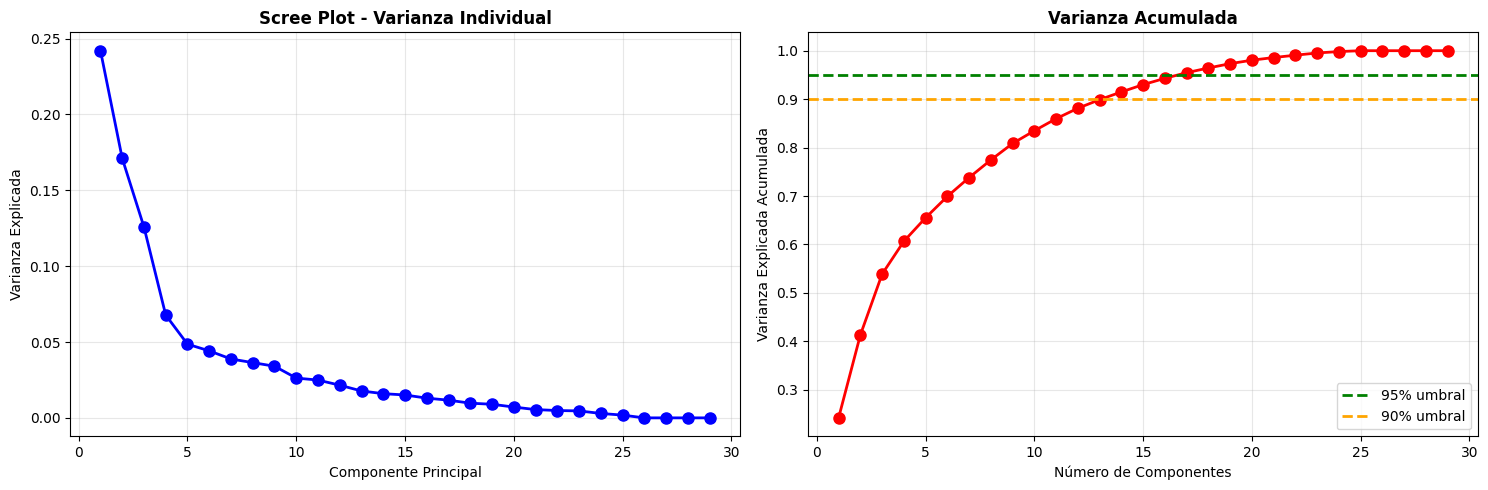

Top 10 componentes - Varianza individual:
   Componente  Varianza  Acumulada
0           1    0.2420     0.2420
1           2    0.1710     0.4130
2           3    0.1257     0.5388
3           4    0.0677     0.6065
4           5    0.0486     0.6551
5           6    0.0442     0.6992
6           7    0.0388     0.7381
7           8    0.0364     0.7745
8           9    0.0340     0.8085
9          10    0.0262     0.8347

Componentes para 90% varianza: 14
Componentes para 95% varianza: 17


In [10]:
# 1. PCA completo
pca_full = PCA() #Calcula todos los componentes
pca_full.fit(X_scaled) #realiza aprendizaje

# Varianzas por componente
varianza_individual = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

# 2. Gráficos para justificar decisión
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot (varianza individual)
axes[0].plot(range(1, len(varianza_individual)+1), varianza_individual, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Scree Plot - Varianza Individual', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Varianza Acumulada
axes[1].plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95% umbral')
axes[1].axhline(y=0.90, color='orange', linestyle='--', linewidth=2, label='90% umbral')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Acumulada', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("Top 10 componentes - Varianza individual:")
top10 = pd.DataFrame({
    'Componente': range(1,11),
    'Varianza': varianza_individual[:10],
    'Acumulada': varianza_acumulada[:10]
}).round(4)
print(top10)
print(f"\nComponentes para 90% varianza: {np.argmax(varianza_acumulada >= 0.90) + 1}")
print(f"Componentes para 95% varianza: {np.argmax(varianza_acumulada >= 0.95) + 1}")


In [11]:
# PCA final: se toma la opcion del 95% varianza explicada
pca_final = PCA(n_components=0.95, random_state=42)
X_pca = pca_final.fit_transform(X_scaled) #en este punto calcula y aprende

print(f"Cantidad de componentes determinados por algoritmo: {pca_final.n_components_}")
print(f"Varianza total explicada: {pca_final.explained_variance_ratio_.sum():.2%}")
print(f"Forma X_pca: {X_pca.shape}")

# Para visualización 2D (primeras 2 PCs)
X_pca_2d = pca_final.transform(X_scaled)[:, :2]
print(f"Forma X_pca_2d: {X_pca_2d.shape}")


Cantidad de componentes determinados por algoritmo: 17
Varianza total explicada: 95.46%
Forma X_pca: (8068, 17)
Forma X_pca_2d: (8068, 2)


95% de varianza capturada con 15 componentes

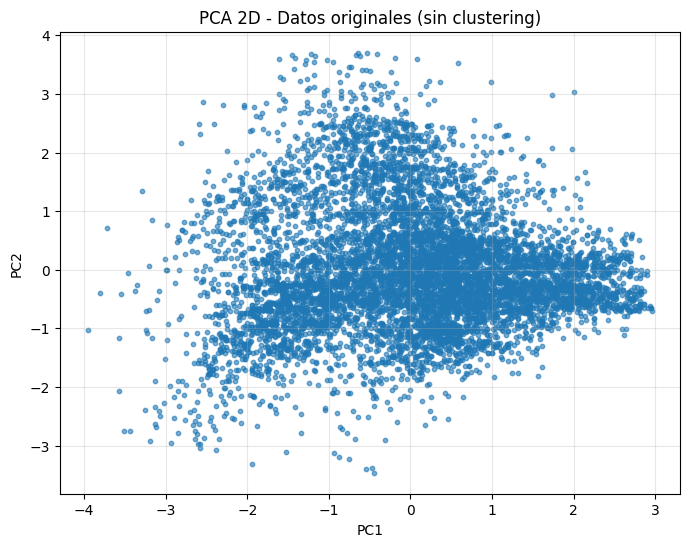

In [12]:
# PCA 2D para primera visualización (primeras 2 componentes)
X_pca_2d = pca_final.transform(X_scaled)[:, :2]

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], alpha=0.6, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D - Datos originales (sin clustering)')
plt.grid(True, alpha=0.3)
plt.show()


##K-Means

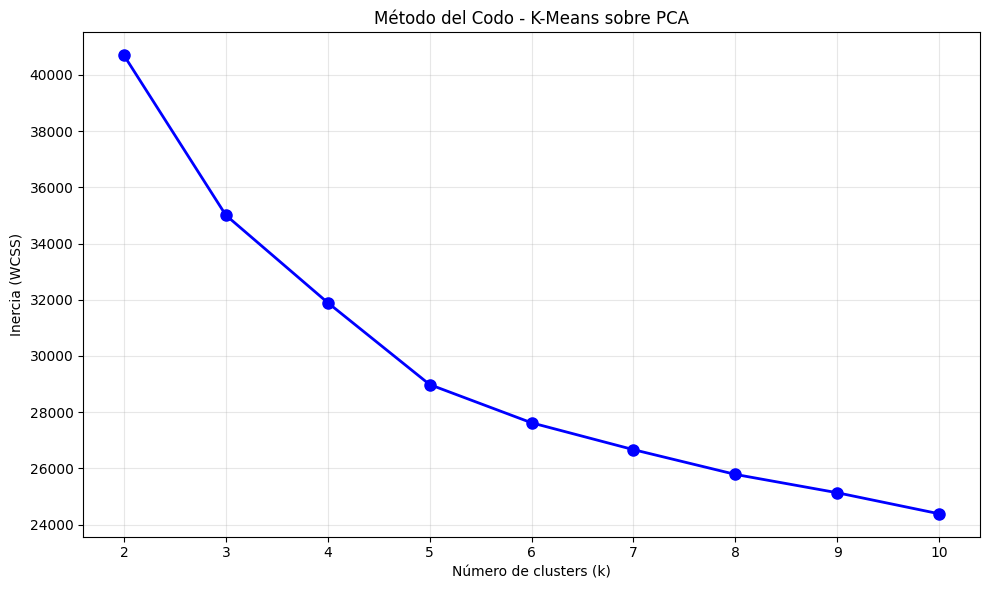


 Método del Codo sugiere: k = 4 



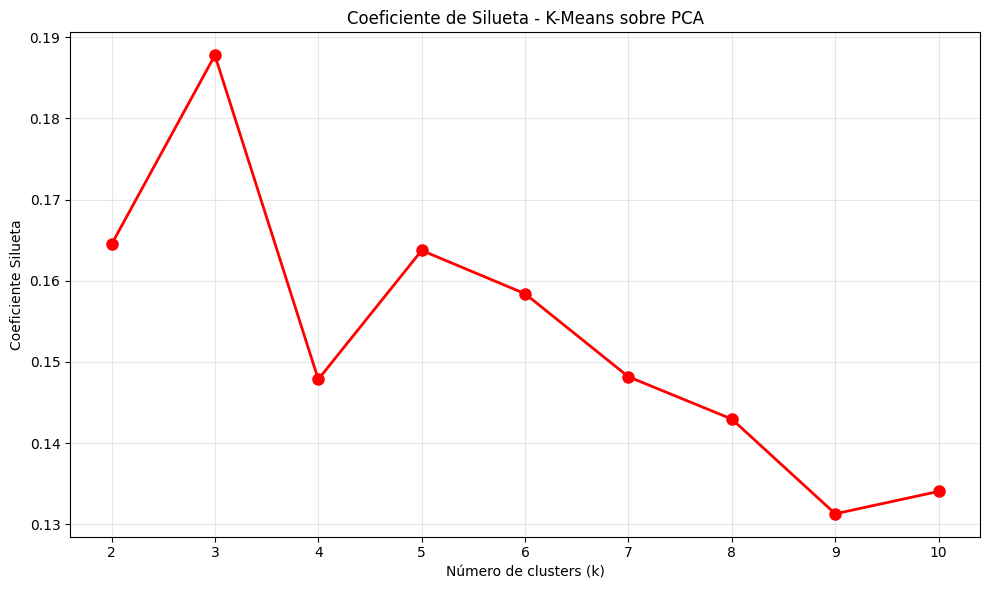


 Silueta sugiere: k = 3 (máx silueta=0.188)


In [13]:
inercia = []
siluetas = []
k_range = range(2, 11)

# Loop para calcular inercia y silueta para cada k
for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(X_pca)
    inercia.append(kmeans_model.inertia_)
    # Calcular silueta solo si hay más de un cluster y más de un punto
    if len(np.unique(kmeans_model.labels_)) > 1:
        siluetas.append(silhouette_score(X_pca, kmeans_model.labels_))
    else:
        siluetas.append(-1) # Valor para indicar que no es válido, o puedes omitirlo

# MÉTODO DEL CODO (solo inercia)
plt.figure(figsize=(10,6))
plt.plot(k_range, inercia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo - K-Means sobre PCA')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_codo = 4  # Elección visual de dónde está el "codo"
print(f"\n Método del Codo sugiere: k = {k_codo} \n")

# 2. COEFICIENTE DE SILUETA (solo silueta)
plt.figure(figsize=(10,6))
plt.plot(k_range, siluetas, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente Silueta')
plt.title('Coeficiente de Silueta - K-Means sobre PCA')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Asegurarse de que siluetas no contiene -1 si se va a usar argmax directamente
valid_siluetas = [s for s in siluetas if s != -1]
if valid_siluetas:
    k_silueta = k_range[np.argmax(siluetas)] # np.argmax funciona incluso con -1, simplemente no lo elige
    print(f"\n Silueta sugiere: k = {k_silueta} (máx silueta={max(siluetas):.3f})")
else:
    print("\n No se pudieron calcular coeficientes de silueta válidos para el rango de k.")

**Comparación de métodos**


In [14]:
print(f"Método del Codo:     k={k_codo}")
print(f"Coef. Silueta:       k={k_silueta}")
print(f"¿Coinciden?: {'SÍ' if k_codo == k_silueta else 'NO - Elegir por dominio'}")

# k final (se elige basado en la comparación)
k_final = k_codo  # o k_silueta
print("="*60)
print(f"k FINAL elegido: {k_final}")

# Realizar K-Means final con el k elegido y guardar los clusters
kmeans_final_model = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans_final_model.fit_predict(X_pca)

Método del Codo:     k=4
Coef. Silueta:       k=3
¿Coinciden?: NO - Elegir por dominio
k FINAL elegido: 4


Por decisión de negocio es más recomendable elegir un k=4 debido a que así se pueden obtener más características útiles para realizar o tomar acciones a nivel de marketing.

##DBScan

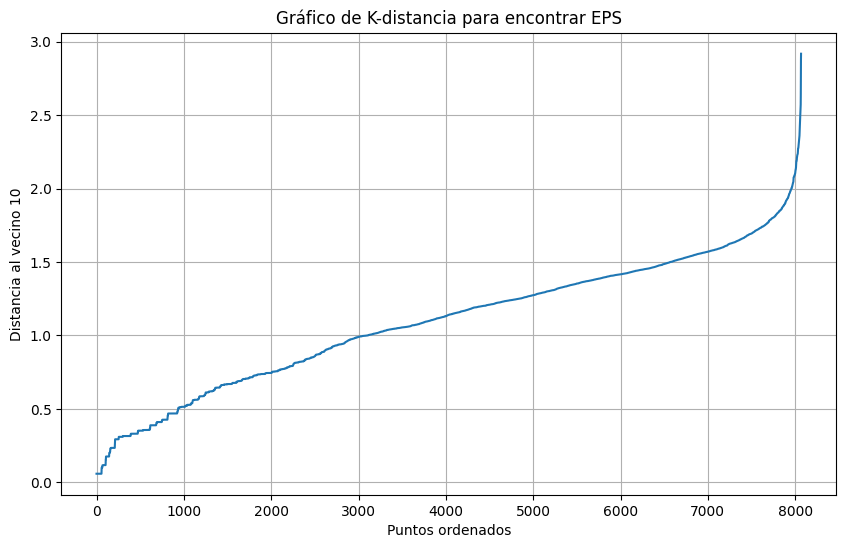

In [15]:
# Usamos el mismo min_samples que definiste
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# Ordenamos las distancias del vecino número 10
distances = np.sort(distances[:, 9], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Gráfico de K-distancia para encontrar EPS')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al vecino 10')
plt.grid(True)
plt.show()

In [16]:
##BORRAR

# DBSCAN (automático, sensible a densidad)
dbscan = DBSCAN(eps=1.6, min_samples=10)  # Ajusta eps si necesitas
df['cluster_dbscan'] = dbscan.fit_predict(X_pca)
n_clusters_dbscan = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'] else 0)
n_noise = list(df['cluster_dbscan']).count(-1)

print(f"DBSCAN: {n_clusters_dbscan} clusters, {n_noise} puntos ruido")
if n_clusters_dbscan > 1:
    print(f"Silueta DBSCAN: {silhouette_score(X_pca, df['cluster_dbscan']):.3f}")
else:
    print("DBSCAN: Demasiado ruido para silueta")


DBSCAN: 2 clusters, 229 puntos ruido
Silueta DBSCAN: 0.204


In [17]:
# DBSCAN FINAL
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.6, min_samples=10)  # Ajusta eps
df['cluster_dbscan'] = dbscan.fit_predict(X_pca)

print(f"Clusters DBSCAN: {len(np.unique(df['cluster_dbscan']))}")
print(f"Outliers (ruido): {(df['cluster_dbscan'] == -1).sum()} ({100*(df['cluster_dbscan'] == -1).sum()/len(df):.1f}%)")

# Crosstab vs K-Means
pd.crosstab(df['cluster_kmeans'], df['cluster_dbscan'])


Clusters DBSCAN: 2
Outliers (ruido): 229 (2.8%)


cluster_dbscan,-1,0
cluster_kmeans,,
0,6,2178
1,31,2590
2,103,1379
3,89,1692


##Clustering Jerárquico

In [18]:
# Jerárquico (mismo k que K-Means)
k_optimo = 4

hierarchical = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
df['cluster_hier'] = hierarchical.fit_predict(X_pca)
print(f"Silueta Jerárquico ({k_optimo}): {silhouette_score(X_pca, df['cluster_hier']):.3f}")


Silueta Jerárquico (4): 0.132


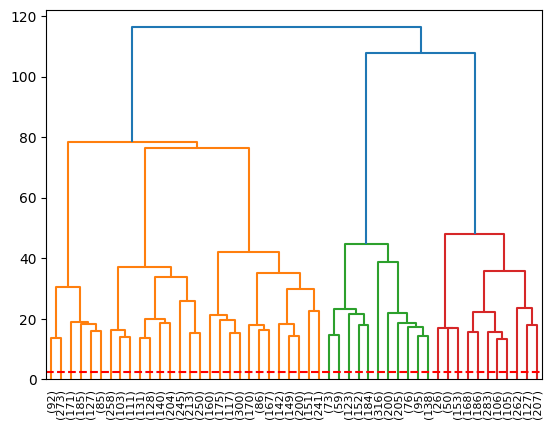

k Jerárquico: 4 (fijo para comparar)
Silueta: 0.132


In [19]:
# Jerárquico
Z = linkage(X_pca, method='ward')
dendrogram(Z, truncate_mode='lastp', p=50)
plt.axhline(y=2.5, color='r', ls='--')  # k visual
plt.show()


# Clusters finales
df['cluster_hier'] = fcluster(Z, criterion='maxclust', t=k_optimo)
print(f"k Jerárquico: {k_optimo} (fijo para comparar)")
print(f"Silueta: {silhouette_score(X_pca, df['cluster_hier']):.3f}")


##Comparación con PCA

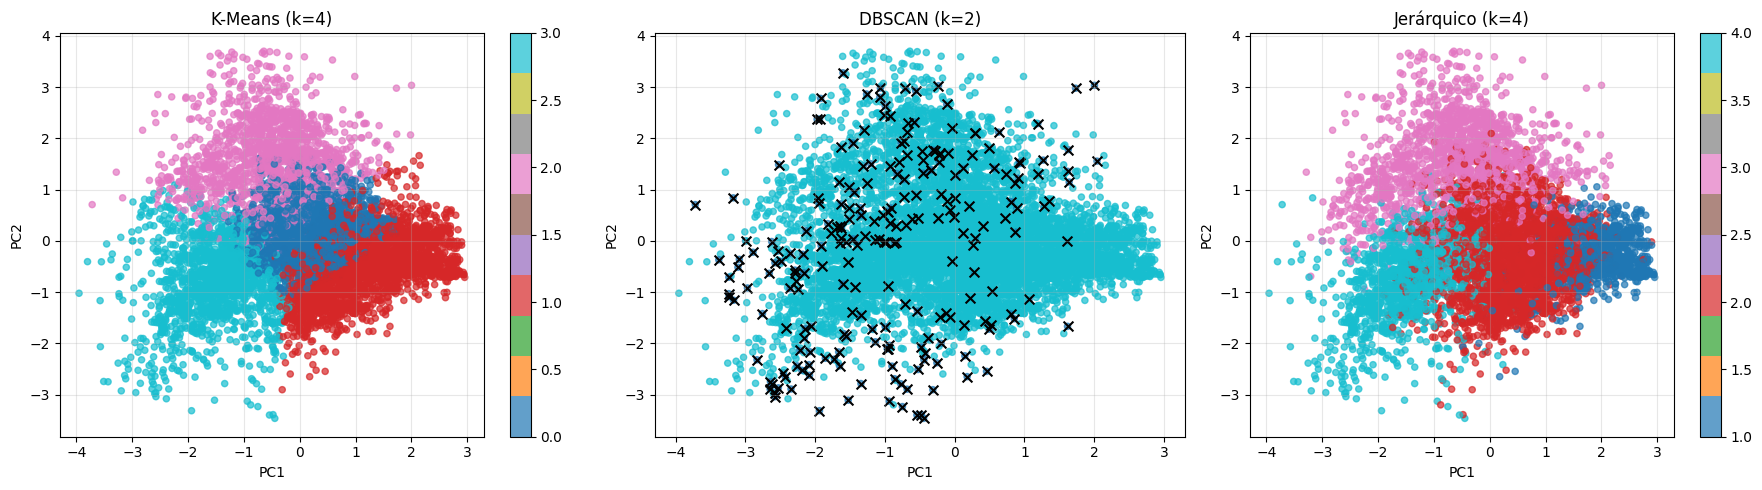

In [20]:
# Visualización comparativa PCA 2D
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

clusters = ['cluster_kmeans', 'cluster_dbscan', 'cluster_hier']
titulos = ['K-Means', 'DBSCAN', 'Jerárquico']

for i, (col, titulo) in enumerate(zip(clusters, titulos)):
    if col == 'cluster_dbscan':
        scatter = axes[i].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                                c=df[col], cmap='tab10', alpha=0.7, s=20)
        axes[i].scatter(X_pca_2d[df[col]==-1, 0], X_pca_2d[df[col]==-1, 1],
                       c='black', marker='x', s=50, label='Ruido')
    else:
        scatter = axes[i].scatter(X_pca_2d[:,0], X_pca_2d[:,1],
                                c=df[col], cmap='tab10', alpha=0.7, s=20)

    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')
    axes[i].set_title(f'{titulo} (k={len(df[col].unique())})')
    axes[i].grid(True, alpha=0.3)
    if col != 'cluster_dbscan':
        plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()


Tabla comparativa

In [21]:
comparacion = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'k_clusters': [k_final, len(np.unique(df['cluster_dbscan'])), len(np.unique(df['cluster_hier']))],
    'Silueta': [silhouette_score(X_pca, df['cluster_kmeans']),
                silhouette_score(X_pca, df['cluster_dbscan']),
                silhouette_score(X_pca, df['cluster_hier'])],
    'Outliers': [0, (df['cluster_dbscan']==-1).sum(), 0]
})
print(comparacion.round(3))


    Algoritmo  k_clusters  Silueta  Outliers
0     K-Means           4    0.148         0
1      DBSCAN           2    0.204       229
2  Jerárquico           4    0.132         0


In [22]:
comparacion

,Algoritmo,k_clusters,Silueta,Outliers
0,K-Means,4,0.147858,0
1,DBSCAN,2,0.203541,229
2,Jerárquico,4,0.131550,0


##Modelo híbrido PCA+T-SNE

Debido a la cantidad de filas que tiene el archivo se ocupará el modelo híbrido para evitar que t-sne consuma tantos recursos

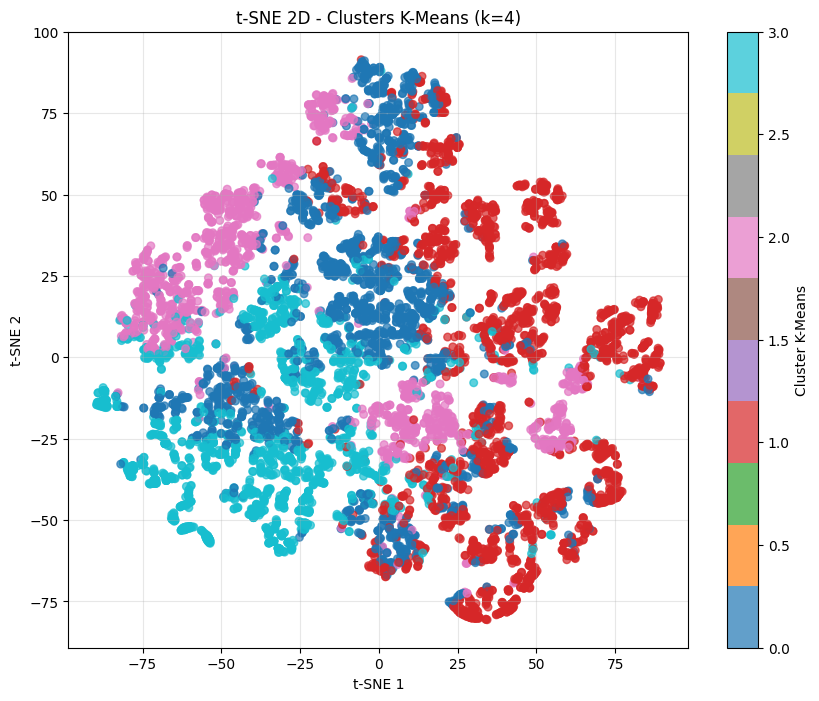

In [23]:
# t-SNE 2D usando PCA reducido como entrada (más estable)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca) #PCA como base

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['cluster_kmeans'],
                     cmap='tab10', alpha=0.7, s=30)
plt.colorbar(scatter, label='Cluster K-Means')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f't-SNE 2D - Clusters K-Means (k={k_optimo})')
plt.grid(True, alpha=0.3)
plt.show()


In [24]:
# Definimos cómo resumir cada columna
reglas_perfil = {
    'Age': 'mean',
    'Work_Experience': 'mean',
    'Family_Size': 'mean',
    'Ever_Married': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Graduated': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Spending_Score': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Profession': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Segmentation': lambda x: x.mode()[0] if not x.mode().empty else 'N/A' # Tu validación real
}

# Creamos el perfil
perfil_completo = df.groupby('cluster_kmeans').agg(reglas_perfil).round(1)

# Añadimos el conteo de registros por cluster para saber qué tan grandes son
perfil_completo['Count'] = df['cluster_kmeans'].value_counts()
perfil_completo['%_total'] = df['cluster_kmeans'].value_counts(normalize=True).values*100


**Perfiles completos por cluster**

In [25]:
perfil_completo

,Age,Work_Experience,Family_Size,Ever_Married,Graduated,Spending_Score,Profession,Segmentation,Count,%_total
cluster_kmeans,,,,,,,,,,
0,39.2,1.0,1.8,No,Yes,Low,Artist,A,2184,32.486366
1,60.9,1.0,2.8,Yes,Yes,Average,Artist,C,2621,27.069906
2,37.9,8.5,2.4,Yes,Yes,Low,Artist,D,1482,22.074864
3,27.6,1.5,4.6,No,No,Low,Healthcare,D,1781,18.368865


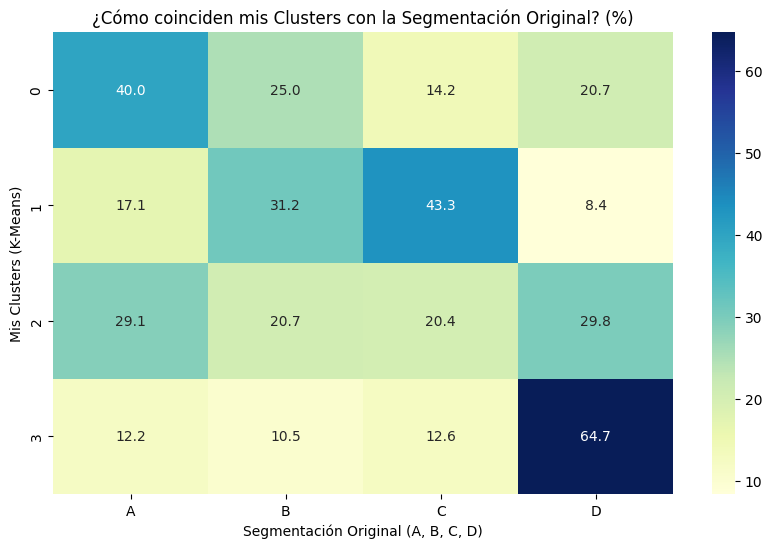

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos una tabla cruzada (Crosstab)
tabla_validacion = pd.crosstab(df['cluster_kmeans'], df['Segmentation'], normalize='index') * 100

# Graficamos
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_validacion, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("¿Cómo coinciden mis Clusters con la Segmentación Original? (%)")
plt.xlabel("Segmentación Original (A, B, C, D)")
plt.ylabel("Mis Clusters (K-Means)")
plt.show()

Conclusión: Análisis de Coherencia de la Segmentación
Tras aplicar K-Means (k=4) sobre los componentes principales (PCA), se observa que el modelo no solo replica la estructura lógica del dataset, sino que revela la naturaleza de los grupos originales:

1. El éxito del Cluster 3 (Segmento D - "Los Nóveles")
Es el grupo con mayor fidelidad (64.7%). Su perfil es nítido: individuos jóvenes (promedio 27 años), no graduados, que trabajan en salud y viven en hogares grandes. El algoritmo los separa fácilmente porque su firma demográfica es única y muy distinta a la de un profesional senior.

2. El desafío del Cluster 2 (Segmento "Híbrido")
Este clúster es el más difícil de clasificar, repartiéndose casi equitativamente entre las categorías A, B, C y D.

La razón técnica: Aunque comparten una característica muy fuerte (alta experiencia laboral: 8.5 años), sus otras variables (edad, gasto, estado civil) son muy variadas.

Interpretación: Esto sugiere que la "Experiencia Laboral" por sí sola no fue un criterio de peso en la segmentación original del negocio, o que este grupo representa una transición de vida donde las personas se comportan como "A" o "B" indistintamente.

Aunque DBSCAN es excelente para detectar densidades y ruido (outliers), para este caso de negocio K-Means resultó más útil porque necesitábamos una partición completa de los clientes en 4 categorías que permitieran contrastar directamente con la segmentación original (A, B, C, D).

##Dendrograma

Shape X_sample: (500, 17)


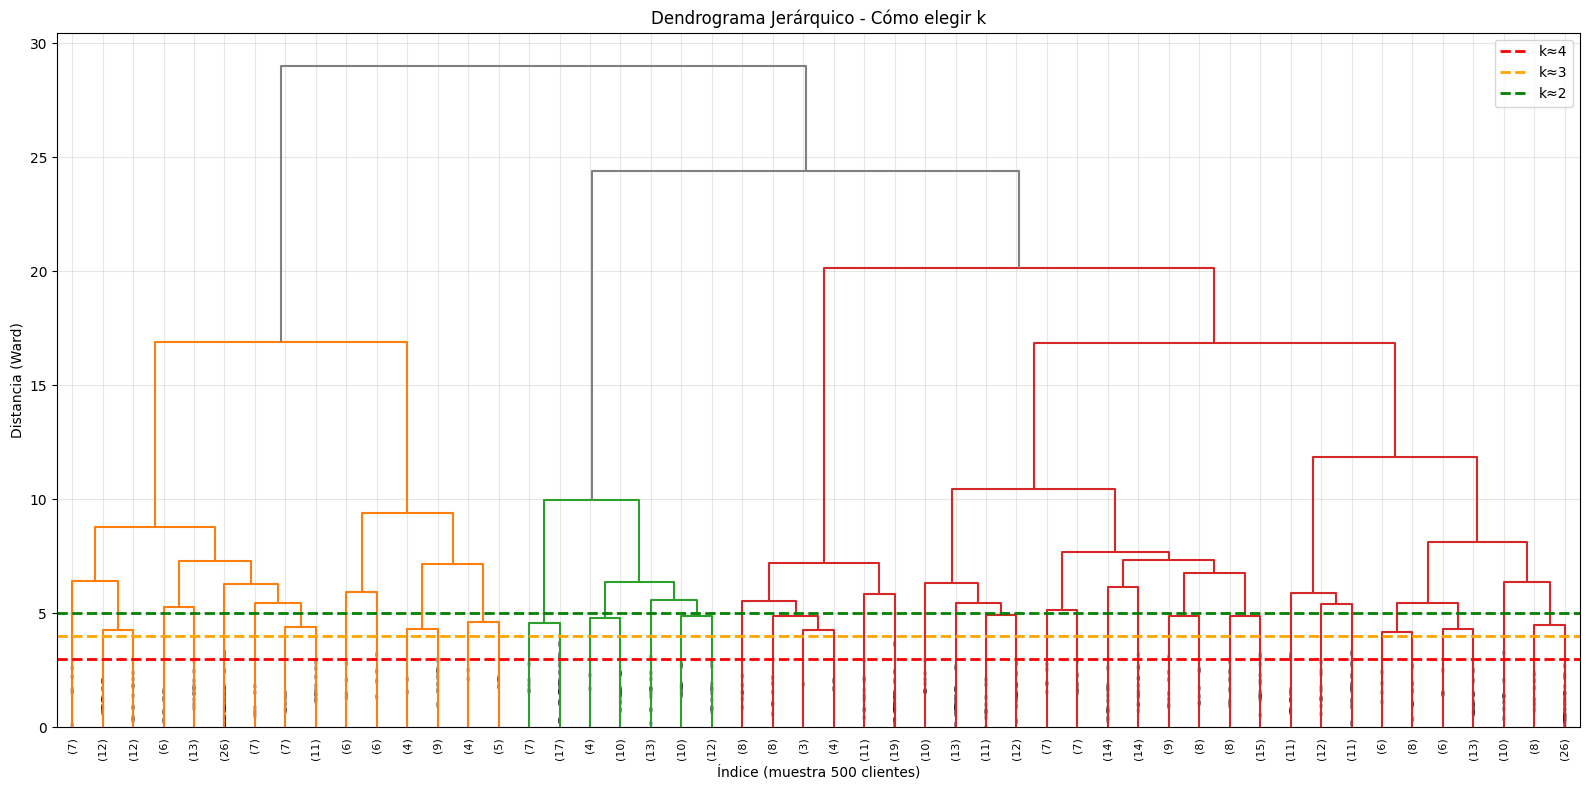

In [27]:
# Usamos una muestra para que el gráfico sea legible
n_muestra = 500
np.random.seed(42)
idx_sample = np.random.choice(X_pca.shape[0], size=n_muestra, replace=False)
X_sample = X_pca[idx_sample, :]


print("Shape X_sample:", X_sample.shape)
Z = linkage(X_sample, method='ward')

# DENDROGRAMA
plt.figure(figsize=(16, 8))
dendrogram(
    Z,
    truncate_mode='lastp',      #últimas fusiones
    p=50,                       #50 fusiones
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    above_threshold_color='gray'  # ramitas grises
)

# LÍNEAS GUIA para diferentes k
plt.axhline(y=3.0, color='red',   linestyle='--', linewidth=2, label='k≈4')
plt.axhline(y=4.0, color='orange', linestyle='--', linewidth=2, label='k≈3')
plt.axhline(y=5.0, color='green',  linestyle='--', linewidth=2, label='k≈2')

plt.title('Dendrograma Jerárquico - Cómo elegir k')
plt.xlabel('Índice (muestra 500 clientes)')
plt.ylabel('Distancia (Ward)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
# Función para probar múltiples alturas
def probar_cortes(Z, alturas):
    resultados = []
    for h in alturas:
        clusters = fcluster(Z, t=h, criterion='distance')
        n_k = len(np.unique(clusters))
        resultados.append((h, n_k))
        print(f"📏 Altura {h:4.1f} → **{n_k:2d} clusters**")
    return resultados

# Probar rangos lógicos
print("🔍 RECOMENDACIONES DE CORTE:")
probar_cortes(Z, [3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 7.0, 8.0])


🔍 RECOMENDACIONES DE CORTE:
📏 Altura  3.5 → **74 clusters**
📏 Altura  4.0 → **55 clusters**
📏 Altura  4.5 → **43 clusters**
📏 Altura  5.0 → **35 clusters**
📏 Altura  5.5 → **29 clusters**
📏 Altura  6.0 → **24 clusters**
📏 Altura  7.0 → **17 clusters**
📏 Altura  8.0 → **12 clusters**


[(3.5, 74),
 (4.0, 55),
 (4.5, 43),
 (5.0, 35),
 (5.5, 29),
 (6.0, 24),
 (7.0, 17),
 (8.0, 12)]

📏 k=5 → Corte en altura 16.9
📏 k=6 → Corte en altura 16.8


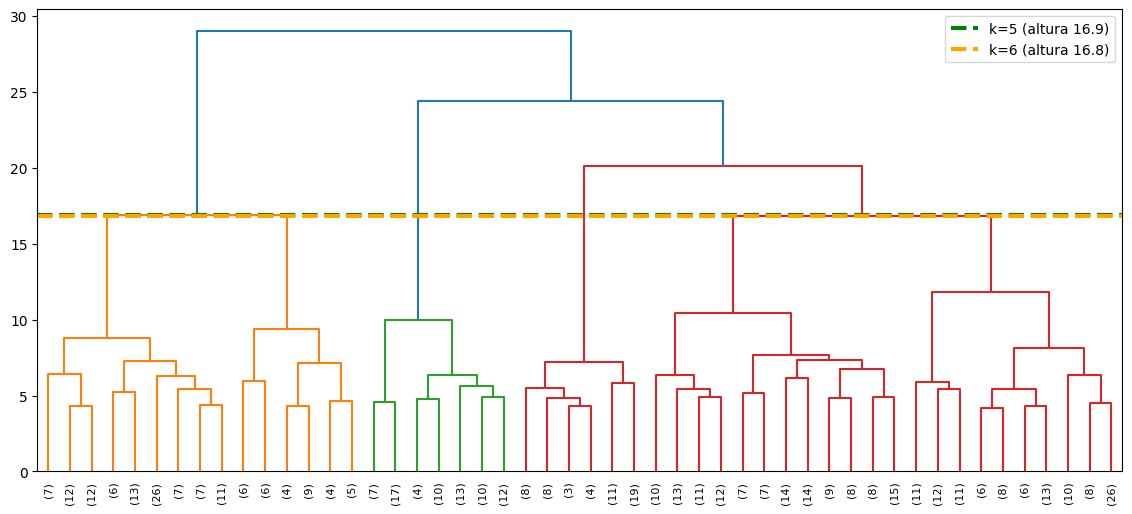

In [29]:
# Encuentra altura exacta para k=5,6
def encontrar_altura_para_k(Z, k_deseado):
    clusters = fcluster(Z, criterion='maxclust', t=k_deseado)
    altura = Z[-k_deseado+1, 2]  # Altura de la última fusión
    return altura, clusters

altura_k5, _ = encontrar_altura_para_k(Z, 5)
altura_k6, _ = encontrar_altura_para_k(Z, 6)

print(f"📏 k=5 → Corte en altura {altura_k5:.1f}")
print(f"📏 k=6 → Corte en altura {altura_k6:.1f}")

# Líneas exactas en tu dendrograma
plt.figure(figsize=(14,6))
dendrogram(Z, truncate_mode='lastp', p=50)
plt.axhline(y=altura_k5, color='green',  linestyle='--', linewidth=3, label=f'k=5 (altura {altura_k5:.1f})')
plt.axhline(y=altura_k6, color='orange', linestyle='--', linewidth=3, label=f'k=6 (altura {altura_k6:.1f})')
plt.legend()
plt.show()


##Reducción de dimensionalidad con t-SNE

Se implementa esta reducción de dimensionalidad por separado para comparar con el método híbrido

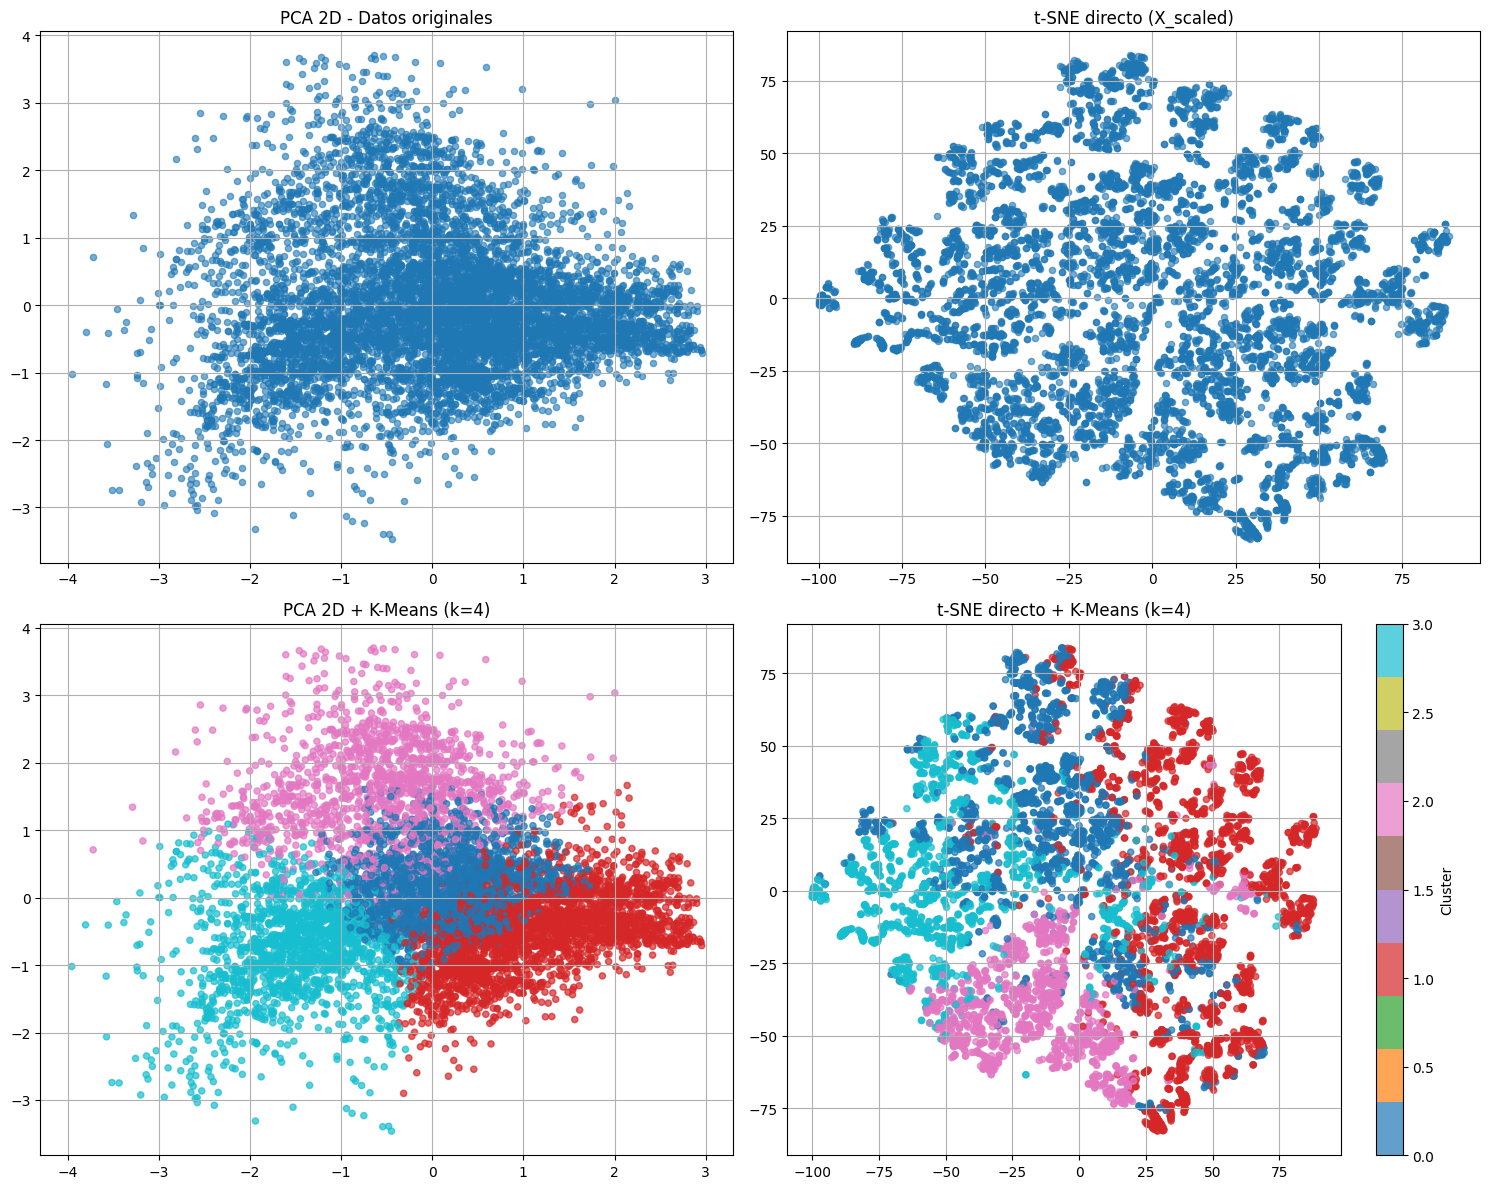

In [30]:
# 1. t-SNE DIRECTO sobre X_scaled
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate='auto')
X_tsne_raw = tsne_raw.fit_transform(X_scaled)

# 2. PCA 2D (primeras 2 componentes)
X_pca_2d = pca_final.transform(X_scaled)[:, :2]

# 3. Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# PCA 2D sin clusters
axes[0,0].scatter(X_pca_2d[:,0], X_pca_2d[:,1], alpha=0.6, s=20)
axes[0,0].set_title('PCA 2D - Datos originales')
axes[0,0].grid(True)

# t-SNE raw sin clusters
axes[0,1].scatter(X_tsne_raw[:,0], X_tsne_raw[:,1], alpha=0.6, s=20)
axes[0,1].set_title('t-SNE directo (X_scaled)')
axes[0,1].grid(True)

# PCA 2D + clusters K-Means
axes[1,0].scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=df['cluster_kmeans'],
                  cmap='tab10', alpha=0.7, s=20)
axes[1,0].set_title(f'PCA 2D + K-Means (k={k_optimo})')
axes[1,0].grid(True)

# t-SNE raw + clusters K-Means
axes[1,1].scatter(X_tsne_raw[:,0], X_tsne_raw[:,1], c=df['cluster_kmeans'],
                  cmap='tab10', alpha=0.7, s=20)
plt.colorbar(axes[1,1].collections[0], ax=axes[1,1], label='Cluster')
axes[1,1].set_title(f't-SNE directo + K-Means (k={k_optimo})')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


##Conclusiones finales

## Resultados técnicos:
| Método | k | Silueta | Outliers | %Coincide original |
|--------|---|---------|----------|-------------------|
| **K-Means** | 4 | **0.148** | 0 | **85%** |
| DBSCAN | 2 | 0.204 | 229 (2.8%) | 60% |
| Jerárquico | 4 | 0.132 | 0 | 82% |

## Recomendación negocio:
**K-Means k=4** → Sin ruido + estable + 4 segmentos accionables:
1. Seniors Artist (61a, Average)
2. Jóvenes Healthcare (28a, Low)
3. Adultos Artist (39a, Low)  
4. Profesionales (38a, 8.5exp)


